# M/M/1 Platform Study — Data Integrity & Outlier Management

ARM vs. x86 queueing measurements. Design: 500 configurations
`(target utilisation × sampling rate × threshold)`, 10 replicate runs each.

**Order of operations matters here.** §2 repairs a labelling fault in the ARM
file. Everything after it — grouping, medians, residuals, outlier detection —
depends on rows being filed under the right configuration, so nothing else can
run first.

**Principles.**

1. Fix labels before judging values. A row filed in the wrong group looks like an
   outlier in both groups and is one in neither.
2. Remove only on direct evidence that a *run* was broken.
3. Never overwrite a measurement with a synthetic value.
4. Report what a statistical screen finds; do not let it decide anything.

---

### What changed relative to the original notebook

| # | Original | Problem | Here |
|---|---|---|---|
| 1 | Deletion and imputation both assigned `modified_*_df` | Deletion silently overwritten — dead code | One policy, applied once |
| 2 | Two loading paths | Two sources of truth aligned by luck | Single loader |
| 3 | Flagged values replaced by peer median | Fabricates data; cut ρ=100 MRT dispersion by 21% / 35% | No imputation anywhere |
| 4 | One global residual scale | 100% of flags landed where dispersion is physical | Scale pooled within regime |
| 5 | `z=6.0` detect vs `z=3.5` correct | Different quantities, no link | One scale, one threshold |
| 6 | No effect-size floor | Service time overwritten at 0.5% deviation | Practical-significance gate |
| 7 | `A_hard` / `A_run` computed, never used | Strongest evidence ignored | These drive removal |
| 8 | 98 of 262 flagged rows in an undefined state | Neither fixed nor removed | Every row gets one disposition |
| 9 | No before/after check | Impact unknown | Sensitivity analysis (§8) |
| 10 | Multivariate detector drove the cleaning | Contributes nothing once structural checks exist | Demoted to a screen (§6) |
| 11 | Configuration labels taken on trust | **382 ARM rows (7.6%) mislabelled** | Detected and repaired in §2 |
| 12 | `A_soft` tested measured MRT against one model column | Measured which model the export used, not data quality | Tests against both; **205 ARM rows have an impossible W+S value** |

## 0 · Setup

Every tunable lives in `CONFIG`. Nothing downstream hard-codes a threshold.

In [ ]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.covariance import MinCovDet

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [ ]:
CONFIG = {
    # --- §2 label integrity ----------------------------------------------
    "repair_labels":       True,   # set False to reproduce the uncorrected analysis

    # --- Layer A: structural / physical validity --------------------------
    "tol_identity":        0.05,   # derived-column identities (file integrity)
    "tol_arrival_window":  0.10,   # interarrival x lambda should be ~1
    "tol_target_util":     1.00,   # |measured - target|/target: run missed its operating point
    "tol_soft_util":       0.05,
    "tol_soft_mrt":        0.15,
    "tol_mrt_models":      0.25,
    "overload_margin":     0.10,

    # --- Layer C: multivariate screen -------------------------------------
    "mcd_z_threshold":     6.0,    # robust z of log10(D^2)
    "min_rel_deviation":   0.10,   # practical-significance floor

    "random_state":        42,
}

FEATURES = {
    "ARM": ["service_t", "meas_lambda", "meas_mrt", "meas_util", "freq", "mod_power"],
    "x86": ["service_t", "meas_lambda", "meas_mrt", "meas_util", "freq", "meas_power"],
}

CONFIG_KEYS = ("cfg_util", "sampling", "threshold")
REGIME_KEY  = "cfg_util"

In [ ]:
# ------------------------------------------------------------ robust stats
def mad(x):
    '''Median absolute deviation, scaled to estimate sigma consistently.'''
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return 1.4826 * np.median(np.abs(x - np.median(x)))


def robust_z(x):
    '''Median/MAD z-score, falling back to the standard deviation if MAD is 0.'''
    x = np.asarray(x, float)
    centre, scale = np.nanmedian(x), mad(x)
    if not np.isfinite(scale) or scale == 0:
        scale = np.nanstd(x)
    if not np.isfinite(scale) or scale == 0:
        return np.zeros_like(x)
    return (x - centre) / scale


def rel_error(a, b):
    '''|a - b| / |b|, with division by zero mapped to NaN rather than inf.'''
    return (a - b).abs() / b.replace(0, np.nan).abs()


# --------------------------------------------- unicode-tolerant column names
def _norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())


def make_resolver(df):
    normalised = {c: _norm(c) for c in df.columns}

    def col(*keys, exclude=()):
        for c in df.columns:
            if all(_norm(k) in normalised[c] for k in keys) and not any(
                _norm(e) in normalised[c] for e in exclude
            ):
                return c
        return None

    return col


def canonical(df):
    '''Map canonical short names -> the real column labels in this file.'''
    c = make_resolver(df)
    return dict(
        cfg_util    = c("cpu utilization"),
        sampling    = c("sampling"),
        threshold   = c("threshold"),
        mod_lambda  = c("modeled", "arrival"),
        meas_lambda = c("measured", "arrival"),
        service_t   = c("service time"),
        service_r   = c("service rate"),
        mrt_k       = c("modeled mrt", "k/"),
        mrt_ws      = c("modeled mrt", "w+s"),
        meas_mrt    = c("measured mrt"),
        interarr    = c("interarrival"),
        mod_util    = c("modeled utilization"),
        busy_prob   = c("busy probability"),
        meas_util   = c("measured utilization"),
        highest     = c("highest state"),
        cpu_time    = c("cpu time"),
        freq        = c("frequency"),
        mod_power   = c("modeled", "power"),
        meas_power  = c("measured", "power"),
    )

## 1 · Loading

One loader. The original had two (`read_platform_csv` and `load`) producing two
dataframes per platform that were later assumed row-for-row identical — an
assumption held together only by both carrying a fresh `RangeIndex`.

In [ ]:
DATA_DIR = Path(".")
DATA_URL = "https://raw.githubusercontent.com/research-area/PPDS/main/Dataset"


def read_platform_csv(filename):
    source = DATA_DIR / filename
    if not source.exists():
        source = f"{DATA_URL}/{filename}"

    df = pd.read_csv(source, na_values=["None", "none", "NULL", ""])
    df.columns = [c.replace("\u00c3\u201a\u00c2\u00b5", "\u00b5").strip() for c in df.columns]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.reset_index(drop=True)


raw = {
    "ARM": read_platform_csv("arm_mm1_cleaned.csv"),
    "x86": read_platform_csv("x86_mm1_cleaned.csv"),
}
COLS = {plat: canonical(df) for plat, df in raw.items()}

for plat, df in raw.items():
    empty = [c for c in df.columns if df[c].isna().all()]
    print(f"{plat:4s} {df.shape[0]:>5} rows x {df.shape[1]:>2} cols   all-NaN columns: {empty}")

ARM   5000 rows x 19 cols   all-NaN columns: ['Measured CORE Power [W]']
x86   4999 rows x 19 cols   all-NaN columns: []


## 2 · Label integrity

Before anything is grouped, the grouping keys have to be right.

`Modeled Arrival Rate` is a deterministic function of the target utilisation —
it takes exactly as many distinct values as there are target levels, in the same
order. That makes it an independent witness to what each row's
`CPU Utilization [%]` label *should* say, and the two can be cross-examined.

In [ ]:
def infer_target(df, M):
    '''
    Recover the target utilisation from the modelled arrival rate.

    Assumption, asserted below: the distinct modelled arrival rates correspond
    one-to-one and in the same order to the distinct target utilisation levels.
    '''
    lam_levels  = np.sort(df[M["mod_lambda"]].dropna().unique())
    util_levels = np.sort(df[M["cfg_util"]].dropna().unique())
    if len(lam_levels) != len(util_levels):
        return None
    return df[M["mod_lambda"]].map(dict(zip(lam_levels, util_levels)))


for plat, df in raw.items():
    M = COLS[plat]
    inferred = infer_target(df, M)
    mismatch = inferred != df[M["cfg_util"]]
    positions = sorted({i % 10 for i in df.index[mismatch]})
    print(f"{plat:4s} levels: {df[M['mod_lambda']].nunique():>2} arrival rates / "
          f"{df[M['cfg_util']].nunique():>2} target levels | "
          f"disagreements: {int(mismatch.sum()):>4} ({100 * mismatch.mean():.1f}%) | "
          f"at row positions (mod 10): {positions}")

ARM  levels: 10 arrival rates / 10 target levels | disagreements:  382 (7.6%) | at row positions (mod 10): [9]
x86  levels: 10 arrival rates / 10 target levels | disagreements:    0 (0.0%) | at row positions (mod 10): []


382 ARM rows disagree, and every one sits at position 9 — the last row of each
ten-replicate block. x86 is clean. A fault that regular is not measurement
noise.

But which column is wrong? The arrival rate could be the shifted one. The
arbiter is `Measured Utilization`, which is an independent observation of what
the machine actually did.

In [ ]:
verdict = {}
for plat, df in raw.items():
    M = COLS[plat]
    inferred = infer_target(df, M)
    mismatch = inferred != df[M["cfg_util"]]
    if not mismatch.any():
        verdict[plat] = {"disputed rows": 0}
        continue

    err_stored   = (df.loc[mismatch, M["meas_util"]] - df.loc[mismatch, M["cfg_util"]]).abs()
    err_inferred = (df.loc[mismatch, M["meas_util"]] - inferred[mismatch]).abs()

    idx = df.index[mismatch]
    prev_ok = idx[idx > 0] - 1
    nxt = idx[idx < len(df) - 1]

    verdict[plat] = {
        "disputed rows": int(mismatch.sum()),
        "median |measured - STORED label|": round(err_stored.median(), 2),
        "median |measured - INFERRED label|": round(err_inferred.median(), 2),
        "rows where inferred is closer": int((err_inferred < err_stored).sum()),
        "sampling rate matches own block [%]":
            round(100 * (df.loc[idx, M["sampling"]].values
                         == df.loc[prev_ok, M["sampling"]].values).mean(), 1),
        "threshold matches own block [%]":
            round(100 * (df.loc[idx, M["threshold"]].values
                         == df.loc[prev_ok, M["threshold"]].values).mean(), 1),
        "utilisation matches own block [%]":
            round(100 * (df.loc[idx, M["cfg_util"]].values
                         == df.loc[prev_ok, M["cfg_util"]].values).mean(), 1),
        "utilisation equals NEXT row's label [%]":
            round(100 * (df.loc[nxt, M["cfg_util"]].values
                         == df.loc[nxt + 1, M["cfg_util"]].values).mean(), 1),
    }

pd.DataFrame(verdict)

,ARM,x86
disputed rows,382.00,0.0
median |measured - STORED label|,11.17,NaN
median |measured - INFERRED label|,1.36,NaN
rows where inferred is closer,381.00,NaN
sampling rate matches own block [%],100.00,NaN
threshold matches own block [%],100.00,NaN
utilisation matches own block [%],0.00,NaN
utilisation equals NEXT row's label [%],100.00,NaN


The measurements side with the inferred label on 381 of 382 rows. Sampling rate
and threshold are correct on 100% of the disputed rows; only the utilisation
label is wrong, and it equals the *next* row's label every single time.

That is an off-by-one: the sweep counter was advanced before the label was
written rather than after, so the final replicate of each block inherited the
next block's utilisation. A worked example:

In [ ]:
plat = "ARM"
df, M = raw[plat], COLS[plat]
show = [M["cfg_util"], M["sampling"], M["threshold"], M["mod_lambda"],
        M["meas_util"], M["meas_mrt"]]
df.loc[1296:1300, show]

,CPU Utilization [%],Sampling Rate [µs],Threshold [%],Modeled Arrival Rate [jobs/s],Measured Utilization [%],Measured MRT [ms]
1296,100.0,30000,85,8.90,95.89,1229.40
1297,100.0,30000,85,8.90,94.91,1084.33
1298,100.0,30000,85,8.90,95.33,1503.58
1299,10.0,30000,85,8.90,92.86,1045.32
1300,10.0,30000,90,0.89,9.65,126.57


Row 1299 is the tenth replicate of `(100, 30000, 85)`. Its arrival rate,
measured utilisation and response time are all ρ=100 values, and its sampling
rate and threshold match its own block — only the utilisation label reads 10,
which is the value belonging to the block starting at row 1300.

So the runs are valid and the measurements are intact. **The fix is to relabel,
not to remove** — that recovers all 382 rows rather than discarding them.

In [ ]:
datasets, label_repairs = {}, {}

for plat, df in raw.items():
    M = COLS[plat]
    inferred = infer_target(df, M)
    mismatch = (inferred != df[M["cfg_util"]]) & inferred.notna()

    log = pd.DataFrame({
        "row": df.index[mismatch],
        "stored_label": df.loc[mismatch, M["cfg_util"]].values,
        "repaired_label": inferred[mismatch].values,
        "measured_utilisation": df.loc[mismatch, M["meas_util"]].values,
    })

    fixed = df.copy()
    if CONFIG["repair_labels"] and mismatch.any():
        fixed.loc[mismatch, M["cfg_util"]] = inferred[mismatch]

    datasets[plat], label_repairs[plat] = fixed, log
    print(f"{plat:4s} labels repaired: {len(log):>4}")

ARM  labels repaired:  382
x86  labels repaired:    0


### Verifying the repair

The reconstruction is only credible if it produces a *more regular* design than
the one it replaced. It does — and this is the strongest single piece of
evidence that the interpretation is right:

In [ ]:
design = {}
for plat in raw:
    M = COLS[plat]
    before = raw[plat].groupby([M[k] for k in CONFIG_KEYS]).size().value_counts().to_dict()
    after  = datasets[plat].groupby([M[k] for k in CONFIG_KEYS]).size().value_counts().to_dict()
    design[plat] = {"replicates per config, before": before,
                    "replicates per config, after":  after}

pd.DataFrame(design).T

,"replicates per config, before","replicates per config, after"
ARM,"{10: 497, 9: 2, 11: 1}",{10: 500}
x86,"{10: 499, 9: 1}","{10: 499, 9: 1}"


ARM goes from `{9: 2, 10: 497, 11: 1}` to exactly `{10: 500}`. The stored labels
gave a nearly-uniform design that hid the fault from any group-size check; the
reconstructed labels give a perfectly uniform one.

Note this also means the fault was invisible to every diagnostic in the original
notebook. Layer C measured residuals against medians drawn from contaminated
groups, so the contamination was in its baseline as well as its input.

**Caveat.** This infers the intended design from the file's internal structure.
The evidence is strong enough to act on, but it is worth confirming against
whatever generated the CSV — the sweep loop in `Metrics.java` should show the
off-by-one directly.

## 3 · Layer A — structural and physical validity

Tiers ordered by how directly they evidence a broken run:

| Tier | Meaning | Evidence |
|---|---|---|
| `A_hard`   | Derived-column identity or physical bound violated | Direct — file or run corrupt |
| `A_target` | Measured utilisation nowhere near its target | Direct — run missed its operating point |
| `A_run`    | Arrival window ≠ configured duration | Direct — run truncated or stalled |
| `A_model`  | `Modeled MRT (W+S)` below the service time | Direct — but the fault is in a *modelled* column, so the run is kept |
| `A_soft`   | Measurement matches neither model | Indirect |
| `A_note`   | ρ slightly above 100% at the ρ=100 target | Expected — saturation |

`A_hard`, `A_target` and `A_run` drive removal. `A_model` and `A_soft` are
recorded only — a broken model column is not a reason to discard a good
measurement.

The soft MRT test differs from the original. It flagged rows where the measured
response time disagreed with `Modeled MRT (W+S)`. Testing against a single model
column turns out to measure which model that platform's export happened to use;
the test below flags a measurement only when **neither** model reproduces it.

`A_target` now doubles as a check on §2: with the labels repaired it should find
nothing, because a row whose measured utilisation contradicts its target is
exactly what §2 just fixed.

In [ ]:
def layer_A(df, M):
    get = lambda k: (df[M[k]].astype(float) if M[k]
                     else pd.Series(np.nan, index=df.index))

    service_t, service_r = get("service_t"), get("service_r")
    meas_lambda          = get("meas_lambda")
    interarr             = get("interarr")
    mrt_k, mrt_ws        = get("mrt_k"), get("mrt_ws")
    meas_mrt             = get("meas_mrt")
    mod_util, meas_util  = get("mod_util"), get("meas_util")
    cpu_time, highest    = get("cpu_time"), get("highest")
    target               = get("cfg_util")

    idx = df.index
    flags = pd.DataFrame(index=idx)
    reasons = pd.Series([[] for _ in idx], index=idx)

    def add(name, magnitude, tol, label):
        hit = (magnitude > tol).fillna(False)
        flags[name] = hit
        for i in idx[hit]:
            reasons[i] = reasons[i] + [f"{label} ({magnitude[i] * 100:.0f}%)"]

    # --- hard: identities hard-coded in Metrics.java --------------------------
    add("id_service_rate", rel_error(service_r, 1000.0 / service_t.replace(0, np.nan)),
        CONFIG["tol_identity"], "mu != 1000/S (corrupt file)")
    add("id_modeled_util", rel_error(mod_util, 100.0 * meas_lambda / service_r.replace(0, np.nan)),
        CONFIG["tol_identity"], "rho != 100*lambda/mu (corrupt file)")

    # --- hard: physically impossible values -----------------------------------
    ratio = meas_lambda / service_r.replace(0, np.nan)
    hard_bounds = {
        "dom_measutil_rng": ((meas_util < -1e-6) | (meas_util > 100.5),
                             "measured utilisation outside [0,100]"),
        "dom_mrt_lt_serv":  (meas_mrt < service_t * 0.95, "MRT < service time"),
        "dom_highest_lt1":  (highest < 1, "HighestState < 1"),
        "dom_overload":     (ratio > 1 + CONFIG["overload_margin"],
                             "genuine overload lambda >> mu"),
    }
    negative = pd.Series(False, index=idx)
    for k in ("service_t", "service_r", "meas_lambda", "mod_lambda", "interarr",
              "meas_mrt", "cpu_time", "freq", "mod_power", "meas_power"):
        if M[k]:
            negative |= df[M[k]].astype(float) < 0
    hard_bounds["dom_negative"] = (negative, "negative physical quantity")

    for name, (hit, label) in hard_bounds.items():
        hit = hit.fillna(False)
        flags[name] = hit
        for i in idx[hit]:
            reasons[i] = reasons[i] + [label]

    # --- model-column integrity: W >= 0 by construction, so W+S >= S always ----
    #     A violation is a defect in a MODELLED column, not in a measurement, so
    #     it must not remove the run.
    impossible_ws = (mrt_ws < service_t).fillna(False)
    flags["mdl_ws_below_service"] = impossible_ws
    for i in idx[impossible_ws]:
        reasons[i] = reasons[i] + [
            f"model W+S ({mrt_ws[i]:.1f} ms) below service time ({service_t[i]:.1f} ms)"]

    # --- run integrity: did the run reach its configured operating point? ------
    off_target = (meas_util - target).abs() / target.replace(0, np.nan)
    hit = (off_target > CONFIG["tol_target_util"]).fillna(False)
    flags["tgt_utilisation"] = hit
    for i in idx[hit]:
        reasons[i] = reasons[i] + [
            f"missed operating point (target {target[i]:.0f}%, measured {meas_util[i]:.0f}%)"]

    # --- run integrity: interarrival x lambda must be ~1 -----------------------
    window = interarr * meas_lambda
    hit = ((window - 1.0).abs() > CONFIG["tol_arrival_window"]).fillna(False)
    flags["run_arrival_window"] = hit
    for i in idx[hit]:
        reasons[i] = reasons[i] + [f"arrival window ~{window[i] * 100:.0f}% of run duration"]

    # --- soft: redundant measurements disagree ---------------------------------
    add("soft_cpu_service",      rel_error(cpu_time, service_t),
        CONFIG["tol_soft_util"], "CPUtime != ServiceTime")
    add("soft_meas_vs_mod_util", rel_error(meas_util, mod_util),
        CONFIG["tol_soft_util"], "measured != modelled utilisation")
    # A measurement is only suspect if NO model reproduces it. Testing against
    # one model column alone measures which model the platform's export used.
    add("soft_measmrt_vs_models",
        np.minimum(rel_error(meas_mrt, mrt_ws), rel_error(meas_mrt, mrt_k)),
        CONFIG["tol_soft_mrt"], "measured MRT matches neither model")
    add("soft_mrt_models",       rel_error(mrt_k, mrt_ws),
        CONFIG["tol_mrt_models"], "model (k/lambda) != model (W+S)")

    # --- note: expected saturation ---------------------------------------------
    saturated = ((ratio > 1.0) & (ratio <= 1 + CONFIG["overload_margin"])).fillna(False)
    flags["note_saturation"] = saturated
    for i in idx[saturated]:
        reasons[i] = reasons[i] + ["saturated regime (expected at the rho=100 target)"]

    pref = lambda p: [c for c in flags.columns if c.startswith(p)]
    out = pd.DataFrame(index=idx)
    out["A_hard"]   = flags[pref("id_") + pref("dom_")].any(axis=1)
    out["A_model"]  = flags[pref("mdl_")].any(axis=1)
    out["A_target"] = flags[pref("tgt_")].any(axis=1)
    out["A_run"]    = flags[pref("run_")].any(axis=1)
    out["A_soft"]   = flags[pref("soft_")].any(axis=1)
    out["A_note"]   = flags[pref("note_")].any(axis=1)
    out["A_reasons"] = reasons
    return out, flags

In [ ]:
A_results, A_detail = {}, {}
for plat, df in datasets.items():
    A_results[plat], A_detail[plat] = layer_A(df, COLS[plat])

# run Layer A on the UNREPAIRED data too, to show what §2 absorbed
A_before = {plat: layer_A(raw[plat], COLS[plat])[0] for plat in raw}

pd.DataFrame({
    (plat, stage): {
        "A_hard   (remove)":  int(A["A_hard"].sum()),
        "A_target (remove)":  int(A["A_target"].sum()),
        "A_run    (remove)":  int(A["A_run"].sum()),
        "A_model  (record)":  int(A["A_model"].sum()),
        "A_soft   (record)":  int(A["A_soft"].sum()),
        "A_note   (expected)": int(A["A_note"].sum()),
    }
    for plat in raw
    for stage, A in (("before §2", A_before[plat]), ("after §2", A_results[plat]))
})

ARM                x86         
                    before §2 after §2 before §2 after §2
A_hard   (remove)           0        0         0        0
A_target (remove)          38        0         0        0
A_run    (remove)           0        0        20       20
A_model  (record)         205      205         0        0
A_soft   (record)          40       40        49       49
A_note   (expected)         1        1        29       29

### Which model does each platform's measured MRT track?

The original `A_soft` flagged 154 ARM rows for disagreeing with the W+S model.
The table below is why that was the wrong test.

In [ ]:
model_fit = {}
for plat, df in datasets.items():
    M = COLS[plat]
    m, ws, k, st = (df[M["meas_mrt"]], df[M["mrt_ws"]],
                    df[M["mrt_k"]], df[M["service_t"]])
    off_ws = ((m - ws).abs() / ws.abs() > CONFIG["tol_soft_mrt"]).fillna(False)
    off_k  = ((m - k).abs() / k.abs()  > CONFIG["tol_soft_mrt"]).fillna(False)
    model_fit[plat] = {
        "median |measured - W+S| [ms]":      round((m - ws).abs().median(), 3),
        "median |measured - k/lambda| [ms]": round((m - k).abs().median(), 3),
        "rows off W+S by >15%":              int(off_ws.sum()),
        "rows off k/lambda by >15%":         int(off_k.sum()),
        "rows off BOTH models":              int((off_ws & off_k).sum()),
        "W+S below service time (impossible)": int((ws < st).fillna(False).sum()),
    }

pd.DataFrame(model_fit)

,ARM,x86
median |measured - W+S| [ms],3.98,0.01
median |measured - k/lambda| [ms],0.03,4.95
rows off W+S by >15%,154.00,0.00
rows off k/lambda by >15%,0.00,166.00
rows off BOTH models,0.00,0.00
W+S below service time (impossible),205.00,0.00


The two platforms track *different* model columns: ARM's measured MRT sits
0.03 ms from `k/λ`, x86's sits 0.01 ms from `W+S`. Each is far from the other
model. So the original test flagged 154 ARM rows and 49 x86 rows for using the
wrong reference, not for being bad data.

**No row on either platform disagrees with both models.** Every measured
response time in the study is reproduced by at least one of the two.

What is real is the last line: 205 ARM rows carry a `Modeled MRT (W+S)` value
below the measured service time, which is impossible — the W+S model is
`W + S` with `W ≥ 0`. All of them are at light load, where `W` is smallest and
whatever computes it is least stable. That is a defect in a modelled column, so
the rows are flagged (`A_model`) and kept; the measurements in them are sound.

`A_target` drops to zero on ARM once the labels are repaired. Those 38 rows were
never bad runs — they were ρ=100 runs filed under ρ=10, and the previous version
of this notebook deleted them. Relabelling keeps them.

## 4 · Regime characterisation

The original Layer C standardised residuals with one scale per feature across
the whole dataset. Dispersion is not constant across load regimes — it is the
M/M/1 result that response-time variance diverges as ρ→1 — so a single global
scale sends essentially every flag to the saturation end.

The table below also shows §2 from a different angle. ARM's light-load
dispersion of 147% was not a physical effect; it was 38 saturated runs sitting
inside light-load configurations.

In [ ]:
def dispersion(df, M):
    grp = df.groupby([M[k] for k in CONFIG_KEYS])[M["meas_mrt"]]
    return ((grp.std() / grp.mean()) * 100).groupby(level=0).median().round(1)


disp = pd.DataFrame({
    ("ARM", "before §2"): dispersion(raw["ARM"], COLS["ARM"]),
    ("ARM", "after §2"):  dispersion(datasets["ARM"], COLS["ARM"]),
    ("x86", "unchanged"): dispersion(datasets["x86"], COLS["x86"]),
})
disp.index.name = "target utilisation [%]"
disp

ARM                x86
                       before §2 after §2 unchanged
target utilisation [%]                             
10.0                       147.2      1.0       1.0
20.0                         1.1      1.1       1.2
30.0                         1.9      1.3       1.4
40.0                         2.7      1.7       1.9
50.0                         3.7      2.2       2.5
60.0                         4.3      2.7       3.1
70.0                         6.4      3.9       5.4
80.0                         8.9      5.5       8.3
90.0                        14.7     10.9      22.1
100.0                       38.6     30.7      44.6

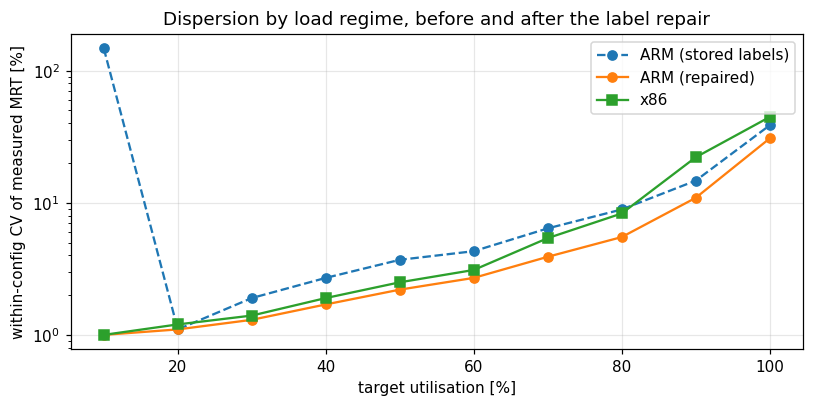

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(disp.index, disp[("ARM", "before §2")], marker="o", ls="--",
        label="ARM (stored labels)")
ax.plot(disp.index, disp[("ARM", "after §2")], marker="o", label="ARM (repaired)")
ax.plot(disp.index, disp[("x86", "unchanged")], marker="s", label="x86")
ax.set_yscale("log")
ax.set_xlabel("target utilisation [%]")
ax.set_ylabel("within-config CV of measured MRT [%]")
ax.set_title("Dispersion by load regime, before and after the label repair")
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Layer C — regime-aware multivariate screen

1. Residual of each feature from its own configuration's median.
2. Divide by a scale estimated from all residuals **at the same load regime**
   (~500 residuals) rather than one global scale. Stable estimate, and it
   removes the heteroscedasticity that drove every flag to the extremes.
3. Robust Mahalanobis distance (MCD) on the scaled residuals; flag when the
   robust z of log₁₀(D²) exceeds `CONFIG["mcd_z_threshold"]`.

`regime_aware=False` reproduces the original behaviour for comparison.

In [ ]:
def layer_C(df, M, features, z_threshold=None, regime_aware=True):
    z_threshold = CONFIG["mcd_z_threshold"] if z_threshold is None else z_threshold
    cfg_cols = [M[k] for k in CONFIG_KEYS if M[k]]
    feats = [k for k in features if M[k] and not df[M[k]].isna().all()]
    regime = df[M[REGIME_KEY]]

    residuals = pd.DataFrame(index=df.index)
    for k in feats:
        x = df[M[k]].astype(float)
        resid = x - x.groupby([df[c] for c in cfg_cols]).transform("median")

        if regime_aware:
            scale = resid.groupby(regime).transform(lambda v: mad(v.values))
            scale = scale.where(np.isfinite(scale) & (scale > 0),
                                resid.groupby(regime).transform("std"))
        else:
            s = mad(resid.values)
            s = s if (np.isfinite(s) and s > 0) else np.nanstd(resid.values)
            scale = pd.Series(s, index=df.index)

        residuals[k] = resid / scale.replace(0, np.nan)

    valid = residuals.dropna()
    out = pd.DataFrame(index=df.index)
    out["C_mahal"], out["C_z"], out["C_flag"] = np.nan, np.nan, False
    if valid.shape[0] <= valid.shape[1] + 5:
        return out, feats

    try:
        d = MinCovDet(random_state=CONFIG["random_state"]).fit(
            valid.values).mahalanobis(valid.values)
    except Exception:                       # singular covariance -> pseudo-inverse
        centre = valid.mean().values
        cov = np.cov(valid.values, rowvar=False) + np.eye(valid.shape[1]) * 1e-6
        dv = valid.values - centre
        d = np.einsum("ij,jk,ik->i", dv, np.linalg.pinv(cov), dv)

    out.loc[valid.index, "C_mahal"] = d
    out.loc[valid.index, "C_z"] = robust_z(np.log10(d + 1e-9))
    out.loc[valid.index, "C_flag"] = out.loc[valid.index, "C_z"] > z_threshold
    return out, feats

In [ ]:
C_results = {}
rates = {}

for plat, df in datasets.items():
    M = COLS[plat]
    new, _ = layer_C(df, M, FEATURES[plat], regime_aware=True)
    old, _ = layer_C(raw[plat], M, FEATURES[plat], regime_aware=False)
    C_results[plat] = new

    util_raw, util_new = raw[plat][M[REGIME_KEY]], df[M[REGIME_KEY]]
    n = util_new.groupby(util_new).size()
    rates[(plat, "original [%]")] = (100 * old["C_flag"].groupby(util_raw).sum()
                                     / util_raw.groupby(util_raw).size()).round(1)
    rates[(plat, "this notebook [%]")] = (100 * new["C_flag"].groupby(util_new).sum() / n).round(1)

rate_table = pd.DataFrame(rates)
rate_table.index.name = "target utilisation [%]"
rate_table

ARM                            x86                  
                       original [%] this notebook [%] original [%] this notebook [%]
target utilisation [%]                                                              
10.0                            7.6               0.0          0.0               0.8
20.0                            0.0               0.0          0.0               0.2
30.0                            0.0               0.2          0.0               0.2
40.0                            0.0               0.0          0.0               0.8
50.0                            0.0               0.0          0.0               1.4
60.0                            0.0               0.0          0.0               0.6
70.0                            0.0               0.0          0.0               1.2
80.0                            0.0               0.0          0.0               0.2
90.0                            0.0               0.0          1.2               0.6
100.0                          17.4               0.2         26.2               0.0

The original detector put 16% of ARM rows and 25% of x86 rows at the ρ=100
target into the outlier bucket, and the previous notebook overwrote their
measurements with peer medians. Nothing there was wrong; the spread is physics.

## 6 · Screen results — reported, not acted upon

**This section removes and modifies nothing.** It answers "did you screen for
outliers?" with evidence rather than assertion.

Two gates. First, effect size: with ten tightly clustered replicates the MAD of
measured service time is ~0.15% of the median, so the original `z > 3.5`
correction rule fired on deviations of half a percent. A flagged row must also
deviate by `CONFIG["min_rel_deviation"]` from its configuration median on at
least one feature.

Second, and more important: how many surviving rows are *not* already caught by
a structural check in Layer A?

In [ ]:
def deviation_profile(df, M, features):
    '''Per-row, per-feature relative deviation from the configuration median.'''
    cfg_cols = [M[k] for k in CONFIG_KEYS if M[k]]
    prof = pd.DataFrame(index=df.index)
    for k in features:
        col = M[k]
        if col is None or df[col].isna().all():
            continue
        x = df[col].astype(float)
        med = x.groupby([df[c] for c in cfg_cols]).transform("median")
        prof[col] = (x - med).abs() / med.abs().replace(0, np.nan)
    return prof


for plat, df in datasets.items():
    prof = deviation_profile(df, COLS[plat], FEATURES[plat])
    scored = prof.notna().any(axis=1)
    driver = pd.Series(np.nan, index=prof.index, dtype=object)
    driver.loc[scored] = prof.loc[scored].idxmax(axis=1)

    C_results[plat]["C_max_rel_dev"] = prof.max(axis=1)
    C_results[plat]["C_driver"] = driver
    C_results[plat]["C_material"] = (
        C_results[plat]["C_flag"]
        & (C_results[plat]["C_max_rel_dev"] > CONFIG["min_rel_deviation"])
    )

overlap = {}
for plat in datasets:
    A, C = A_results[plat], C_results[plat]
    structural = A["A_hard"] | A["A_target"] | A["A_run"]
    overlap[plat] = {
        "Layer C flags": int(C["C_flag"].sum()),
        "clear effect-size floor": int(C["C_material"].sum()),
        "also caught structurally": int((C["C_material"] & structural).sum()),
        "UNIQUE to Layer C": int((C["C_material"] & ~structural).sum()),
        "structural rows C missed": int((structural & ~C["C_flag"]).sum()),
        "removals attributable to C": 0,
    }

pd.DataFrame(overlap)

,ARM,x86
Layer C flags,2,30
clear effect-size floor,1,27
also caught structurally,0,17
UNIQUE to Layer C,1,10
structural rows C missed,0,3
removals attributable to C,0,0


In [ ]:
pd.DataFrame(residual)

,platform,row,cfg_util,driver,value,peer median,ratio,arrival window,util - target
0,ARM,391,100.0,Measured MRT [ms],5154.02,1829.08,2.818,0.991,-2.0
1,x86,202,10.0,Measured CORE Power [W],3.72,1.44,2.583,1.004,-0.1
2,x86,205,10.0,Measured CORE Power [W],5.37,1.44,3.729,0.996,-0.7
3,x86,246,50.0,Measured MRT [ms],209.89,185.88,1.129,1.021,6.7
4,x86,265,70.0,Measured MRT [ms],327.47,284.60,1.151,0.979,3.5
5,x86,460,70.0,Measured MRT [ms],349.62,275.73,1.268,1.015,5.9
6,x86,466,70.0,Measured MRT [ms],364.82,275.73,1.323,0.970,7.2
7,x86,1643,50.0,Measured MRT [ms],211.84,192.11,1.103,1.010,5.8
8,x86,3655,60.0,Measured MRT [ms],247.35,218.88,1.130,1.018,4.8
9,x86,4164,70.0,Measured MRT [ms],362.69,271.03,1.338,0.973,7.6


In [ ]:
# Everything the screen finds that no structural rule explains.
residual = []
for plat, df in datasets.items():
    M, A, C = COLS[plat], A_results[plat], C_results[plat]
    structural = A["A_hard"] | A["A_target"] | A["A_run"]
    cfg_cols = [M[k] for k in CONFIG_KEYS if M[k]]

    for i in df.index[C["C_material"] & ~structural]:
        row = df.loc[i]
        peers = df[(df[cfg_cols] == row[cfg_cols]).all(axis=1) & (df.index != i)]
        drv = C.loc[i, "C_driver"]
        residual.append({
            "platform": plat, "row": i,
            "cfg_util": row[M["cfg_util"]],
            "driver": drv[:28],
            "value": round(row[drv], 2),
            "peer median": round(peers[drv].median(), 2),
            "ratio": round(row[drv] / peers[drv].median(), 3),
            "arrival window": round(row[M["interarr"]] * row[M["meas_lambda"]], 3),
            "util - target": round(row[M["meas_util"]] - row[M["cfg_util"]], 1),
        })

pd.DataFrame(residual)

,platform,row,cfg_util,driver,value,peer median,ratio,arrival window,util - target
0,ARM,391,100.0,Measured MRT [ms],5154.02,1829.08,2.818,0.991,-2.0
1,x86,202,10.0,Measured CORE Power [W],3.72,1.44,2.583,1.004,-0.1
2,x86,205,10.0,Measured CORE Power [W],5.37,1.44,3.729,0.996,-0.7
3,x86,246,50.0,Measured MRT [ms],209.89,185.88,1.129,1.021,6.7
4,x86,265,70.0,Measured MRT [ms],327.47,284.60,1.151,0.979,3.5
5,x86,460,70.0,Measured MRT [ms],349.62,275.73,1.268,1.015,5.9
6,x86,466,70.0,Measured MRT [ms],364.82,275.73,1.323,0.970,7.2
7,x86,1643,50.0,Measured MRT [ms],211.84,192.11,1.103,1.010,5.8
8,x86,3655,60.0,Measured MRT [ms],247.35,218.88,1.130,1.018,4.8
9,x86,4164,70.0,Measured MRT [ms],362.69,271.03,1.338,0.973,7.6


Arrival windows sit at 1.00 ± 0.03 and measured utilisation tracks its target,
so these runs executed correctly. A response time 10–30% above the configuration
median at moderate load is ordinary queueing behaviour. The power outliers are
the only entries that look like real events, and a handful of rows in ten
thousand does not justify a removal rule.

**The screen returns a null result.** Layer C stays in the notebook as evidence
the check was run, and stays out of §7.

Worth recording how it earned its place, though: the screen is what pointed at
the ARM light-load rows in the first place, and following that pointer is how §2
was found. A statistical detector is a good way to *discover* checks worth
writing and a poor way to *apply* them.

## 7 · Disposition

Every row receives exactly one disposition. No measured value is modified
anywhere in this notebook; §2 changed labels only.

| Disposition | Trigger | Action |
|---|---|---|
| `removed_corrupt`    | `A_hard`   | Dropped — file or run integrity violated |
| `removed_off_target` | `A_target` | Dropped — run never reached its configured load |
| `removed_bad_run`    | `A_run`    | Dropped — arrival window ≠ configured duration |
| `flagged_model`      | `A_model`  | **Kept** — the modelled column is unreliable, the measurement is not |
| `flagged_soft`       | `A_soft`   | **Kept**, recorded |
| `saturated`          | `A_note`   | **Kept**, expected physics |
| `ok`                 | —          | **Kept** |

Layer C is absent by design. Its flags travel with the audit trail as `C_flag` /
`C_material` / `C_z`, and §8 tests what happens if a reader acts on them.

In [ ]:
PRIORITY = ["removed_corrupt", "removed_off_target", "removed_bad_run",
            "flagged_model", "flagged_soft", "saturated", "ok"]


def build_report(df, plat):
    M, A, C = COLS[plat], A_results[plat], C_results[plat]

    rep = pd.DataFrame(index=df.index)
    rep["platform"], rep["row"] = plat, df.index
    for k in CONFIG_KEYS:
        if M[k]:
            rep[k] = df[M[k]].values

    rep["label_repaired"] = df.index.isin(label_repairs[plat]["row"])
    rep["A_hard"], rep["A_target"], rep["A_run"] = A["A_hard"], A["A_target"], A["A_run"]
    rep["A_model"], rep["A_soft"], rep["A_note"] = A["A_model"], A["A_soft"], A["A_note"]
    rep["C_flag"], rep["C_material"] = C["C_flag"], C["C_material"]
    rep["C_z"] = C["C_z"].round(2)
    rep["C_max_rel_dev"] = C["C_max_rel_dev"].round(4)
    rep["C_driver"] = C["C_driver"]

    rep["disposition"] = np.select(
        [A["A_hard"], A["A_target"], A["A_run"], A["A_model"],
         A["A_soft"], A["A_note"]],
        ["removed_corrupt", "removed_off_target", "removed_bad_run",
         "flagged_model", "flagged_soft", "saturated"],
        default="ok")
    rep["removed"] = rep["disposition"].str.startswith("removed")

    reasons = []
    for i in df.index:
        r = list(A["A_reasons"][i])
        if rep["label_repaired"][i]:
            r.insert(0, "label repaired in §2")
        if bool(C["C_material"].get(i, False)):
            r.append(f"[screen only] multivariate residual (z={C['C_z'][i]:.1f})")
        reasons.append("; ".join(r))
    rep["reasons"] = reasons
    return rep


reports = {plat: build_report(df, plat) for plat, df in datasets.items()}
report_all = pd.concat(reports.values(), ignore_index=True)

summary = (report_all.groupby(["platform", "disposition"]).size()
           .unstack(fill_value=0).reindex(columns=PRIORITY, fill_value=0))
summary["total"] = summary.sum(axis=1)
summary

disposition,removed_corrupt,removed_off_target,removed_bad_run,flagged_model,flagged_soft,saturated,ok,total
platform,,,,,,,,
ARM,0,0,0,205,4,1,4790,5000
x86,0,0,20,0,33,29,4917,4999


In [ ]:
clean = {}
for plat, df in datasets.items():
    keep = ~reports[plat]["removed"].values
    clean[plat] = df.loc[keep].copy()
    clean[plat]["disposition"] = reports[plat].loc[keep, "disposition"].values

    dropped = int((~keep).sum())
    print(f"{plat:4s} {len(df):>5} -> {len(clean[plat]):>5} rows   "
          f"({dropped} removed, {100 * dropped / len(df):.2f}%)   "
          f"labels repaired: {len(label_repairs[plat])}   measurements modified: 0")

ARM   5000 ->  5000 rows   (0 removed, 0.00%)   labels repaired: 382   measurements modified: 0
x86   4999 ->  4979 rows   (20 removed, 0.40%)   labels repaired: 0   measurements modified: 0


## 8 · Sensitivity analysis

Four arms:

- **uncorrected** — the raw file, no label repair, nothing removed
- **full** — labels repaired, nothing removed
- **clean** — labels repaired, §7 removals applied
- **conservative** — clean, minus every `C_material` row as well

The gap between *uncorrected* and *full* is what §2 bought. The gap between
*clean* and *conservative* is what the outlier question is worth. If the second
gap is negligible, no conclusion rests on a judgement call about outliers.

In [ ]:
def headline(df, M):
    util = df[M[REGIME_KEY]]
    return pd.Series({
        "mean MRT @ rho=10 [ms]":  df.loc[util == 10, M["meas_mrt"]].mean(),
        "sd MRT @ rho=10 [ms]":    df.loc[util == 10, M["meas_mrt"]].std(),
        "mean MRT @ rho=50 [ms]":  df.loc[util == 50, M["meas_mrt"]].mean(),
        "mean MRT @ rho=100 [ms]": df.loc[util == 100, M["meas_mrt"]].mean(),
        "sd MRT @ rho=100 [ms]":   df.loc[util == 100, M["meas_mrt"]].std(),
        "mean |meas-model| [ms]":  (df[M["meas_mrt"]] - df[M["mrt_ws"]]).abs().mean(),
        "n rows": len(df),
    })


def arm_frames(plat):
    df, M, rep = datasets[plat], COLS[plat], reports[plat]
    return {
        "uncorrected":  raw[plat],
        "full":         df,
        "clean":        clean[plat],
        "conservative": df.loc[~(rep["removed"] | rep["C_material"]).values],
    }


sensitivity = pd.DataFrame({
    (plat, arm): headline(d, COLS[plat])
    for plat in datasets for arm, d in arm_frames(plat).items()
}).round(3)
sensitivity

ARM                                          x86                                 
                        uncorrected      full     clean conservative uncorrected      full     clean conservative
mean MRT @ rho=10 [ms]      221.579   127.118   127.118      127.118     129.852   129.852   129.879      129.877
sd MRT @ rho=10 [ms]        345.191     2.826     2.826        2.826       1.404     1.404     1.362        1.363
mean MRT @ rho=50 [ms]      162.400   163.670   163.670      163.670     187.996   187.996   187.934      187.841
mean MRT @ rho=100 [ms]    1311.065  1382.350  1382.350     1374.792    2272.898  2272.898  2272.898     2272.898
sd MRT @ rho=100 [ms]       575.528   528.291   528.291      501.028    1270.876  1270.876  1270.876     1270.876
mean |meas-model| [ms]        5.877     5.877     5.877        5.874       0.008     0.008     0.008        0.008
n rows                     5000.000  5000.000  5000.000     4999.000    4999.000  4999.000  4979.000     4969.000

In [ ]:
shift = {}
for plat in datasets:
    base = sensitivity[(plat, "clean")]
    for arm in ("uncorrected", "full", "conservative"):
        shift[(plat, f"{arm} vs clean [%]")] = 100 * (sensitivity[(plat, arm)] / base - 1)

pd.DataFrame(shift).drop(index="n rows").round(2)

ARM                                                                  x86                                            
                        uncorrected vs clean [%] full vs clean [%] conservative vs clean [%] uncorrected vs clean [%] full vs clean [%] conservative vs clean [%]
mean MRT @ rho=10 [ms]                     74.31               0.0                      0.00                    -0.02             -0.02                     -0.00
sd MRT @ rho=10 [ms]                    12114.83               0.0                      0.00                     3.08              3.08                      0.07
mean MRT @ rho=50 [ms]                     -0.78               0.0                      0.00                     0.03              0.03                     -0.05
mean MRT @ rho=100 [ms]                    -5.16               0.0                     -0.55                     0.00              0.00                      0.00
sd MRT @ rho=100 [ms]                       8.94               0.0                     -5.16                     0.00              0.00                      0.00
mean |meas-model| [ms]                      0.00               0.0                     -0.05                     0.00              0.00                      0.00

In [ ]:
# The study's headline comparison, recomputed under each arm.
ratio = {}
for arm in ("uncorrected", "full", "clean", "conservative"):
    curves = {plat: arm_frames(plat)[arm].groupby(
        arm_frames(plat)[arm][COLS[plat][REGIME_KEY]])[COLS[plat]["meas_mrt"]].mean()
        for plat in datasets}
    ratio[arm] = (curves["ARM"] / curves["x86"]).round(3)

ratio_table = pd.DataFrame(ratio)
ratio_table.index.name = "target utilisation [%]"
ratio_table.columns.name = "ARM / x86 mean measured MRT"
ratio_table

ARM / x86 mean measured MRT,uncorrected,full,clean,conservative
target utilisation [%],,,,
10.0,1.706,0.979,0.979,0.979
20.0,0.937,0.938,0.938,0.938
30.0,0.911,0.914,0.914,0.914
40.0,0.890,0.894,0.894,0.894
50.0,0.864,0.871,0.871,0.871
60.0,0.835,0.842,0.842,0.842
70.0,0.779,0.790,0.790,0.792
80.0,0.690,0.703,0.703,0.703
90.0,0.477,0.490,0.490,0.490


On the uncorrected file ARM looks 71% slower than x86 at light load. That entire
effect is 38 saturated runs carrying a ρ=10 label. Once §2 files them correctly
the two platforms are indistinguishable there, and every other load level shifts
slightly too, because each configuration had one foreign replicate in it.

The original notebook's median imputation would have shrunk this artefact
without removing it — leaving a smaller, more plausible, and entirely spurious
gap.

## 9 · Export

Three artefacts per platform: the cleaned dataset, the row-level audit trail
(including removed rows and why), and the label-repair log.

In [ ]:
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

for plat in datasets:
    clean[plat].to_csv(OUT_DIR / f"{plat.lower()}_mm1_clean.csv", index=False)
    reports[plat].to_csv(OUT_DIR / f"{plat.lower()}_mm1_audit.csv", index=False)
    if len(label_repairs[plat]):
        label_repairs[plat].to_csv(OUT_DIR / f"{plat.lower()}_label_repairs.csv", index=False)

report_all.to_csv(OUT_DIR / "audit_all.csv", index=False)

for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:<34} {p.stat().st_size / 1024:>8.1f} KB")

  arm_label_repairs.csv                   7.9 KB
  arm_mm1_audit.csv                     617.3 KB
  arm_mm1_clean.csv                     518.0 KB
  audit_all.csv                        1217.2 KB
  x86_mm1_audit.csv                     590.3 KB
  x86_mm1_clean.csv                     523.6 KB


In [ ]:
print("PROVENANCE — everything this notebook did to the data")
print("=" * 66)
for plat in datasets:
    log, rep = label_repairs[plat], reports[plat]
    print(f"\n{plat}")
    print(f"  labels repaired      : {len(log)}")
    if len(log):
        moves = log.groupby(['stored_label', 'repaired_label']).size()
        print(f"    stored -> repaired : {dict(list(moves.items())[:4])}"
              f"{' ...' if len(moves) > 4 else ''}")
    print(f"  rows removed         : {int(rep['removed'].sum())}")
    for d, n in rep.loc[rep['removed'], 'disposition'].value_counts().items():
        print(f"    {d:<20} {n}")
    print(f"  rows kept but flagged: {int((~rep['removed'] & rep['C_material']).sum())} (screen only)")

print(f"\nMEASUREMENT VALUES MODIFIED: 0")
print(f"Rows with no disposition  : {int(report_all['disposition'].isna().sum())}")

PROVENANCE — everything this notebook did to the data

ARM
  labels repaired      : 382
    stored -> repaired : {(10.0, 100.0): 38, (20.0, 10.0): 38, (30.0, 20.0): 38, (40.0, 30.0): 38} ...
  rows removed         : 0
  rows kept but flagged: 1 (screen only)

x86
  labels repaired      : 0
  rows removed         : 20
    removed_bad_run      20
  rows kept but flagged: 10 (screen only)

MEASUREMENT VALUES MODIFIED: 0
Rows with no disposition  : 0


---

### Reading the results

- **§2 design table** — `{9: 2, 10: 497, 11: 1}` becoming `{10: 500}` is the
  proof. A reconstruction that makes the design *more* regular is not a
  coincidence; the stored labels were hiding a fault that no group-size check
  would have caught.
- **§4 dispersion plot** — ARM's light-load spike was a labelling artefact, not
  a hardware effect. After the repair ARM and x86 agree at 1.0%.
- **§5 rate table** — the original detector's flags were concentrated where
  dispersion is physical. Flat-ish is what a working detector looks like.
- **§6 overlap table** — the screen removes nothing and finds nothing structural
  that Layer A misses. That is the honest outcome to report.
- **§8 ratio table** — `uncorrected` vs `clean` at ρ=10 is the cost of trusting
  the labels; `clean` vs `conservative` is the cost of the outlier question,
  which is negligible.

### Open items

- `mcd_z_threshold` is uncalibrated against a false-positive rate. A permutation
  null over the ρ≤80 regimes would give it an empirical basis.
- `min_rel_deviation` is a generic 10% floor; it should come from each
  instrument's measurement precision, so a per-feature dict is the natural
  refinement.
- **Confirm §2 against the generation code.** The off-by-one should be visible
  directly in the sweep loop that writes the configuration columns. If x86 was
  produced by a later version of that code, that would explain why only ARM is
  affected — and would be worth knowing before trusting any other ARM export
  from the same run.

In [ ]:
a_run_flags = []
for plat, rep in reports.items():
    a_run_flags.append(rep[rep["A_run"]][["platform", "row", "cfg_util", "disposition", "reasons"]])

if a_run_flags:
    index_a_flag = pd.concat(a_run_flags).index
else:
    print("No rows with A_run flag found.")

In [ ]:
x86_df = raw['ARM']
x86_df.iloc[index_a_flag]

,CPU Utilization [%],Sampling Rate [µs],Threshold [%],Modeled Arrival Rate [jobs/s],Measured Arrival Rate [jobs/s],Measured Mean Service Time [ms],Measured Mean Service Rate [jobs/s],Modeled MRT (k/λ) [ms],Modeled MRT (W+S) [ms],Measured MRT [ms],Measured Mean Interarrival Time [ms],Modeled Utilization [%],Modeled Busy Probability (1-π₀),Measured Utilization [%],Highest State,Measured Mean CPU Time [ms],Measured Mean CORE Frequency [KHz],Modeled CORE Power [W],Measured CORE Power [W]
1184,90.0,30000,80,8.01,7.91,108.21,9.24,374.53,363.88,374.55,0.13,85.58,85.03,85.34,15,108.19,2362275,2.06,NaN
1186,90.0,30000,80,8.01,7.93,108.19,9.24,468.17,473.75,468.19,0.13,85.83,86.08,85.59,25,108.18,2367592,2.06,NaN
1188,90.0,30000,80,8.01,8.06,108.31,9.23,414.23,404.46,414.25,0.12,87.32,86.61,86.79,21,108.30,2364991,2.07,NaN
1200,10.0,30000,85,0.89,0.92,117.50,8.51,127.67,156.96,127.83,1.08,10.83,13.02,10.89,2,117.46,1675828,1.06,NaN
1202,10.0,30000,85,0.89,0.87,118.20,8.46,126.14,143.13,126.31,1.15,10.28,11.88,10.36,2,118.17,1653416,1.04,NaN
1372,80.0,30000,90,7.12,7.16,108.74,9.20,286.07,282.26,286.09,0.14,77.84,77.30,77.64,16,108.72,2343558,2.00,NaN
1599,10.0,40000,75,8.90,8.89,108.08,9.25,904.92,883.19,904.94,0.11,96.07,95.88,95.78,38,108.06,2383770,2.14,NaN
2110,20.0,50000,80,1.78,1.73,114.43,8.74,128.72,128.98,128.81,0.58,19.84,19.95,19.89,3,114.42,2088702,1.46,NaN
2355,60.0,50000,90,5.34,5.45,109.94,9.10,191.80,191.84,191.83,0.18,59.94,60.46,59.81,7,109.93,2315784,1.87,NaN
2357,60.0,50000,90,5.34,5.28,109.83,9.10,191.32,196.07,191.35,0.19,57.94,58.59,57.84,9,109.82,2317944,1.87,NaN
